## STEP 5 (RANDOM FOREST) - MODEL TRAINING
#### In this step, we are going to train the Random Forest model for each personality axis and embedding type

## 1. Setup & Utility Functions
In this section, we import all necessary libraries, configure our machine learning modules and define the helper function to split the MBTI target types.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from pipeline.smote_oversampling import SMOTEOversampler
from pipeline.machine_learning_algorithms.random_forest import RandomForestModel

In [ ]:
def divide_mbti(y_series):
    y_df = pd.DataFrame()
    y_df['I_E'] = (y_series.str[0] == 'I').astype(int)
    y_df['N_S'] = (y_series.str[1] == 'N').astype(int)
    y_df['T_F'] = (y_series.str[2] == 'T').astype(int)
    y_df['J_P'] = (y_series.str[3] == 'J').astype(int)
    return y_df

## 2. Data Loading
Loading the pre-processed dataset 

In [ ]:
df = pd.read_pickle('../final_dataset_with_encodings.pkl')
df.head()

,Unnamed: 0,type,posts,augmented_posts,augmented_posts_clean,posts_clean,posts_tfidf_features,posts_w2v_features,augmented_posts_tfidf_features,augmented_posts_w2v_features,I_E,N_S,T_F,J_P
0,0,INFJ,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...,moment sportscenter top ten play prank ha life...,moment sportscenter top ten play prank ha life...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.039469853, -0.3728942, -0.41033414, -0.1154...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.19693445, -0.0025032638, 0.08193041, 0.1530...",I,N,F,J
1,1,ENTP,'I'm finding the lack of me in these posts ver...,I am noticing a significant absence of myself ...,i noticing significant absence post sex monoto...,i finding lack me post alarming sex boring pos...,"[0.0, 0.06762042801527685, 0.0, 0.026240045055...","[0.078822784, -0.31084794, -0.40682986, -0.102...","[0.0, 0.0, 0.06401863001877148, 0.0, 0.0308183...","[0.22643407, 0.13486987, 0.13359053, 0.1418835...",E,N,T,P
2,2,INTP,'Good one _____ https://www.youtube.com/wat...,'Good one _____ https://www.youtube.com/wat...,good one course i say i know blessing curse do...,good one course i say i know blessing curse do...,"[0.0, 0.0, 0.07384879322521598, 0.031627841934...","[0.055956766, -0.31570536, -0.36344454, -0.075...","[0.0, 0.0, 0.0, 0.0, 0.0658605765698715, 0.032...","[0.19347186, 0.021339012, 0.09674486, 0.159254...",I,N,T,P
3,3,INTJ,"'Dear INTP, I enjoyed our conversation the o...","'Dear INTP, I enjoyed our conversation the o...",dear i enjoyed conversation day esoteric gabbi...,dear i enjoyed conversation day esoteric gabbi...,"[0.0, 0.0, 0.0, 0.05044068578091325, 0.0, 0.0,...","[-0.019194897, -0.37407914, -0.5568112, -0.182...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.05199321424315832,...","[0.21894899, 0.21582802, 0.18478529, 0.2388864...",I,N,T,J
4,4,ENTJ,'You're fired.|||That's another silly misconce...,"""You're fired."" ||| That's another common misc...",you fired another common misconception approac...,you fired another silly misconception approach...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.057541147, -0.29415804, -0.45218706, -0.204...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.19203198, 0.121340014, -0.008840058, 0.0499...",E,N,T,J


## 3. Experiment 1: Random Forest with TF-IDF Encodings
In this step, we aplly SMOTE to balance the classess and train the Random Forest models for each personality axis using TF-IDF encodings

In [ ]:
#First we are going to setup the data for TF-IDF
X_tfidf = np.stack(df["augmented_posts_tfidf_features"].values)
y = df["type"]

X_train_tf, X_test_tf, y_train_tf, y_test_tf = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTEOversampler(random_state=42)
X_train_tf_bal, y_train_tf_bal = smote.fit_resample(X_train_tf, y_train_tf)

y_train_tf_4cols = divide_mbti(pd.Series(y_train_tf_bal))
y_test_tf_4cols = divide_mbti(y_test_tf.reset_index(drop=True))

X_train_tf_bal = X_train_tf_bal.astype(np.float32)

Original dataset shape: X=(6940, 10000), y=(6940,)
Resampled dataset shape: X=(23456, 10000), y=(23456,)


#### Training and Evaluation: I_E Axis

In [ ]:
comparison_metrics = {
    'TF_IDF': {
        'I_E' : {'baseline': {}, 'augmented': {}},
        'N_S' : {'baseline': {}, 'augmented': {}},
        'T_F' : {'baseline': {}, 'augmented': {}},
        'J_P' : {'baseline': {}, 'augmented': {}},
    },

    'Word2Vec': {
        'I_E' : {'baseline': {}, 'augmented': {}},
        'N_S' : {'baseline': {}, 'augmented': {}},
        'T_F' : {'baseline': {}, 'augmented': {}},
        'J_P' : {'baseline': {}, 'augmented': {}},
    }
}

In [ ]:
dim = 'I_E'
print(f"Starting Grid Search for TF-IDF ({dim} axis)...")
rf_model = RandomForestModel()
optimizer = rf_model.get_optimizer()
optimizer.fit(X_train_tf_bal, y_train_tf_4cols[dim])
print(f"Best parameters chosen: {optimizer.best_params_}")
rf_model.set_best_model(optimizer.best_estimator_)

acc, prec, rec, f1, report = rf_model.evaluate(X_test_tf, y_test_tf_4cols[dim])

comparison_metrics['TF_IDF'][dim]['augmented'] = {
    'accuracy': acc,
    'precision': prec,
    'recall': rec,
    'f1_score': f1
}

print("========================================")
print(f"Evaluation for dimension: {dim}")
print("========================================")
print(f"Accuracy: {acc:.4f}\n")
print(report)

Starting Grid Search for TF-IDF (I_E axis)...
Best parameters chosen: {'max_depth': 10, 'n_estimators': 50}
Evaluation for dimension: I_E
Accuracy: 0.8329

              precision    recall  f1-score   support

           0       0.78      0.39      0.52       401
           1       0.84      0.97      0.90      1334

    accuracy                           0.83      1735
   macro avg       0.81      0.68      0.71      1735
weighted avg       0.83      0.83      0.81      1735



#### Training and Evaluation: N_S Axis

In [ ]:
dim = 'N_S'
print(f"Starting Grid Search for TF-IDF ({dim} axis)...")
rf_model = RandomForestModel()
optimizer = rf_model.get_optimizer()
optimizer.fit(X_train_tf_bal, y_train_tf_4cols[dim])
print(f"Best parameters chosen: {optimizer.best_params_}")
rf_model.set_best_model(optimizer.best_estimator_)

acc, prec, rec, f1, report = rf_model.evaluate(X_test_tf, y_test_tf_4cols[dim])

comparison_metrics['TF_IDF'][dim]['augmented'] = {
    'accuracy': acc,
    'precision': prec,
    'recall': rec,
    'f1_score': f1
}

print("========================================")
print(f"Evaluation for dimension: {dim}")
print("========================================")
print(f"Accuracy: {acc:.4f}\n")
print(report)

Starting Grid Search for TF-IDF (N_S axis)...
Best parameters chosen: {'max_depth': 20, 'n_estimators': 50}
Evaluation for dimension: N_S
Accuracy: 0.8634

              precision    recall  f1-score   support

           0       0.53      0.12      0.20       240
           1       0.87      0.98      0.93      1495

    accuracy                           0.86      1735
   macro avg       0.70      0.55      0.56      1735
weighted avg       0.83      0.86      0.82      1735



#### Training and Evaluation: T_F Axis

In [ ]:
dim = 'T_F'
print(f"Starting Grid Search for TF-IDF ({dim} axis)...")
rf_model = RandomForestModel()
optimizer = rf_model.get_optimizer()
optimizer.fit(X_train_tf_bal, y_train_tf_4cols[dim])
print(f"Best parameters chosen: {optimizer.best_params_}")
rf_model.set_best_model(optimizer.best_estimator_)

acc, prec, rec, f1, report = rf_model.evaluate(X_test_tf, y_test_tf_4cols[dim])

comparison_metrics['TF_IDF'][dim]['augmented'] = {
    'accuracy': acc,
    'precision': prec,
    'recall': rec,
    'f1_score': f1
}

print("========================================")
print(f"Evaluation for dimension: {dim}")
print("========================================")
print(f"Accuracy: {acc:.4f}\n")
print(report)

Starting Grid Search for TF-IDF (T_F axis)...
Best parameters chosen: {'max_depth': 20, 'n_estimators': 50}
Evaluation for dimension: T_F
Accuracy: 0.7308

              precision    recall  f1-score   support

           0       0.73      0.79      0.76       939
           1       0.73      0.66      0.69       796

    accuracy                           0.73      1735
   macro avg       0.73      0.73      0.73      1735
weighted avg       0.73      0.73      0.73      1735



#### Training and Evaluation: J_P Axis

In [ ]:
dim = 'J_P'
print(f"Starting Grid Search for TF-IDF ({dim} axis)...")
rf_model = RandomForestModel()
optimizer = rf_model.get_optimizer()
optimizer.fit(X_train_tf_bal, y_train_tf_4cols[dim])
print(f"Best parameters chosen: {optimizer.best_params_}")
rf_model.set_best_model(optimizer.best_estimator_)

acc, prec, rec, f1, report = rf_model.evaluate(X_test_tf, y_test_tf_4cols[dim])

comparison_metrics['TF_IDF'][dim]['augmented'] = {
    'accuracy': acc,
    'precision': prec,
    'recall': rec,
    'f1_score': f1
}

print("========================================")
print(f"Evaluation for dimension: {dim}")
print("========================================")
print(f"Accuracy: {acc:.4f}\n")
print(report)

Starting Grid Search for TF-IDF (J_P axis)...
Best parameters chosen: {'max_depth': 20, 'n_estimators': 100}
Evaluation for dimension: J_P
Accuracy: 0.6190

              precision    recall  f1-score   support

           0       0.62      0.99      0.76      1048
           1       0.74      0.06      0.11       687

    accuracy                           0.62      1735
   macro avg       0.68      0.52      0.43      1735
weighted avg       0.66      0.62      0.50      1735



## 4. Experiment 2: Random Forest with Word2Vec Encodings
In this step, we are going to repeat the trainig process using Word2Vec features to compare performance across different embedding types

In [ ]:
# Setup data for Word2Vec
X_w2v = np.stack(df["augmented_posts_w2v_features"].values)

X_train_wv, X_test_wv, y_train_wv, y_test_wv = train_test_split(
    X_w2v, y, test_size=0.2, random_state=42, stratify=y
)

X_train_wv_bal, y_train_wv_bal = smote.fit_resample(X_train_wv, y_train_wv)

y_train_wv_4cols = divide_mbti(pd.Series(y_train_wv_bal))
y_test_wv_4cols = divide_mbti(y_test_wv.reset_index(drop=True))

X_train_wv_bal = X_train_wv_bal.astype(np.float32)

Original dataset shape: X=(6940, 500), y=(6940,)
Resampled dataset shape: X=(23456, 500), y=(23456,)


#### Training and Evaluation: I_E Axis

In [ ]:
dim = 'I_E'
print(f"Starting Grid Search for WORD2VEC ({dim} axis)...")
rf_model = RandomForestModel()
optimizer = rf_model.get_optimizer()
optimizer.fit(X_train_wv_bal, y_train_wv_4cols[dim])
print(f"Best parameters chosen: {optimizer.best_params_}")
rf_model.set_best_model(optimizer.best_estimator_)

acc, prec, rec, f1, report = rf_model.evaluate(X_test_wv, y_test_wv_4cols[dim])

comparison_metrics['Word2Vec'][dim]['augmented'] = {
    'accuracy': acc,
    'precision': prec,
    'recall': rec,
    'f1_score': f1
}

print("========================================")
print(f"Evaluation for dimension: {dim}")
print("========================================")
print(f"Accuracy: {acc:.4f}\n")
print(report)

Starting Grid Search for WORD2VEC (I_E axis)...
Best parameters chosen: {'max_depth': 10, 'n_estimators': 50}
Evaluation for dimension: I_E
Accuracy: 0.8380

              precision    recall  f1-score   support

           0       0.66      0.62      0.64       401
           1       0.89      0.90      0.90      1334

    accuracy                           0.84      1735
   macro avg       0.77      0.76      0.77      1735
weighted avg       0.83      0.84      0.84      1735



#### Training and Evaluation: N_S Axis

In [ ]:
dim = 'N_S'
print(f"Starting Grid Search for WORD2VEC ({dim} axis)...")
rf_model = RandomForestModel()
optimizer = rf_model.get_optimizer()
optimizer.fit(X_train_wv_bal, y_train_wv_4cols[dim])
print(f"Best parameters chosen: {optimizer.best_params_}")
rf_model.set_best_model(optimizer.best_estimator_)

acc, prec, rec, f1, report = rf_model.evaluate(X_test_wv, y_test_wv_4cols[dim])

comparison_metrics['Word2Vec'][dim]['augmented'] = {
    'accuracy': acc,
    'precision': prec,
    'recall': rec,
    'f1_score': f1
}

print("========================================")
print(f"Evaluation for dimension: {dim}")
print("========================================")
print(f"Accuracy: {acc:.4f}\n")
print(report)

Starting Grid Search for WORD2VEC (N_S axis)...
Best parameters chosen: {'max_depth': 20, 'n_estimators': 50}
Evaluation for dimension: N_S
Accuracy: 0.8622

              precision    recall  f1-score   support

           0       0.50      0.46      0.48       240
           1       0.91      0.93      0.92      1495

    accuracy                           0.86      1735
   macro avg       0.71      0.69      0.70      1735
weighted avg       0.86      0.86      0.86      1735



#### Training and Evaluation: T_F Axis

In [ ]:
dim = 'T_F'
print(f"Starting Grid Search for WORD2VEC ({dim} axis)...")
rf_model = RandomForestModel()
optimizer = rf_model.get_optimizer()
optimizer.fit(X_train_wv_bal, y_train_wv_4cols[dim])
print(f"Best parameters chosen: {optimizer.best_params_}")
rf_model.set_best_model(optimizer.best_estimator_)

acc, prec, rec, f1, report = rf_model.evaluate(X_test_wv, y_test_wv_4cols[dim])

comparison_metrics['Word2Vec'][dim]['augmented'] = {
    'accuracy': acc,
    'precision': prec,
    'recall': rec,
    'f1_score': f1
}

print("========================================")
print(f"Evaluation for dimension: {dim}")
print("========================================")
print(f"Accuracy: {acc:.4f}\n")
print(report)

Starting Grid Search for WORD2VEC (T_F axis)...
Best parameters chosen: {'max_depth': 20, 'n_estimators': 100}
Evaluation for dimension: T_F
Accuracy: 0.7372

              precision    recall  f1-score   support

           0       0.75      0.76      0.76       939
           1       0.72      0.71      0.71       796

    accuracy                           0.74      1735
   macro avg       0.74      0.73      0.74      1735
weighted avg       0.74      0.74      0.74      1735



#### Training and Evaluation: J_P Axis

In [ ]:
dim = 'J_P'
print(f"Starting Grid Search for WORD2VEC ({dim} axis)...")
rf_model = RandomForestModel()
optimizer = rf_model.get_optimizer()
optimizer.fit(X_train_wv_bal, y_train_wv_4cols[dim])
print(f"Best parameters chosen: {optimizer.best_params_}")
rf_model.set_best_model(optimizer.best_estimator_)

acc, prec, rec, f1, report = rf_model.evaluate(X_test_wv, y_test_wv_4cols[dim])

comparison_metrics['Word2Vec'][dim]['augmented'] = {
    'accuracy': acc,
    'precision': prec,
    'recall': rec,
    'f1_score': f1
}

print("========================================")
print(f"Evaluation for dimension: {dim}")
print("========================================")
print(f"Accuracy: {acc:.4f}\n")
print(report)

Starting Grid Search for WORD2VEC (J_P axis)...
Best parameters chosen: {'max_depth': 20, 'n_estimators': 100}
Evaluation for dimension: J_P
Accuracy: 0.6035

              precision    recall  f1-score   support

           0       0.64      0.79      0.71      1048
           1       0.50      0.32      0.39       687

    accuracy                           0.60      1735
   macro avg       0.57      0.55      0.55      1735
weighted avg       0.58      0.60      0.58      1735



## 5. Experiment 3: Testing Posts Before Augmentation
In this step, we are going to train and evaluate the Random Forest model using data before textual augmentation


#### Preparing the Original Data (TF-IDF)

In [ ]:
X_tfidf_base = np.stack(df["posts_tfidf_features"].values)
y = df["type"]

X_train_tf_base, X_test_tf_base, y_train_tf_base, y_test_tf_base = train_test_split(
    X_tfidf_base, y, test_size=0.2, random_state=42, stratify=y
)

smote_base = SMOTEOversampler(random_state=42)
X_train_tf_base_bal, y_train_tf_base_bal = smote_base.fit_resample(X_train_tf_base, y_train_tf_base)

y_train_tf_base_4cols = divide_mbti(pd.Series(y_train_tf_base_bal))
y_test_tf_base_4cols = divide_mbti(y_test_tf_base.reset_index(drop=True))

X_train_tf_base_bal = X_train_tf_base_bal.astype(np.float32)

Original dataset shape: X=(6940, 10000), y=(6940,)
Resampled dataset shape: X=(23456, 10000), y=(23456,)


#### Baseline Training and Evaluation (TF-IDF)

In [ ]:
dim = 'I_E'
print(f"Starting Baseline Training for TF-IDF ({dim} axis)...")

rf_model_base = RandomForestModel()
optimizer_base = rf_model_base.get_optimizer()
optimizer_base.fit(X_train_tf_base_bal, y_train_tf_base_4cols[dim])

rf_model_base.set_best_model(optimizer_base.best_estimator_)

acc, prec, rec, f1, report = rf_model_base.evaluate(X_test_tf_base, y_test_tf_base_4cols[dim])

comparison_metrics['TF_IDF'][dim]['baseline'] = {
    'accuracy': acc,
    'precision': prec,
    'recall': rec,
    'f1_score': f1
}

print("========================================")
print(f"Baseline Evaluation for dimension: {dim}")
print("========================================")
print(f"Accuracy: {acc:.4f}\n")
print(report)

Starting Baseline Training for TF-IDF (I_E axis)...
Baseline Evaluation for dimension: I_E
Accuracy: 0.7712

              precision    recall  f1-score   support

           0       0.83      0.01      0.02       401
           1       0.77      1.00      0.87      1334

    accuracy                           0.77      1735
   macro avg       0.80      0.51      0.45      1735
weighted avg       0.79      0.77      0.67      1735



In [ ]:
dim = 'N_S'
print(f"Starting Baseline Training for TF-IDF ({dim} axis)...")

rf_model_base = RandomForestModel()
optimizer_base = rf_model_base.get_optimizer()
optimizer_base.fit(X_train_tf_base_bal, y_train_tf_base_4cols[dim])

rf_model_base.set_best_model(optimizer_base.best_estimator_)

acc, prec, rec, f1, report = rf_model_base.evaluate(X_test_tf_base, y_test_tf_base_4cols[dim])

comparison_metrics['TF_IDF'][dim]['baseline'] = {
    'accuracy': acc,
    'precision': prec,
    'recall': rec,
    'f1_score': f1
}

print("========================================")
print(f"Baseline Evaluation for dimension: {dim}")
print("========================================")
print(f"Accuracy: {acc:.4f}\n")
print(report)

Starting Baseline Training for TF-IDF (N_S axis)...
Baseline Evaluation for dimension: N_S
Accuracy: 0.8617

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       240
           1       0.86      1.00      0.93      1495

    accuracy                           0.86      1735
   macro avg       0.43      0.50      0.46      1735
weighted avg       0.74      0.86      0.80      1735



In [ ]:
dim = 'T_F'
print(f"Starting Baseline Training for TF-IDF ({dim} axis)...")

rf_model_base = RandomForestModel()
optimizer_base = rf_model_base.get_optimizer()
optimizer_base.fit(X_train_tf_base_bal, y_train_tf_base_4cols[dim])

rf_model_base.set_best_model(optimizer_base.best_estimator_)

acc, prec, rec, f1, report = rf_model_base.evaluate(X_test_tf_base, y_test_tf_base_4cols[dim])

comparison_metrics['TF_IDF'][dim]['baseline'] = {
    'accuracy': acc,
    'precision': prec,
    'recall': rec,
    'f1_score': f1
}

print("========================================")
print(f"Baseline Evaluation for dimension: {dim}")
print("========================================")
print(f"Accuracy: {acc:.4f}\n")
print(report)

Starting Baseline Training for TF-IDF (T_F axis)...
Baseline Evaluation for dimension: T_F
Accuracy: 0.7556

              precision    recall  f1-score   support

           0       0.77      0.78      0.78       939
           1       0.74      0.73      0.73       796

    accuracy                           0.76      1735
   macro avg       0.75      0.75      0.75      1735
weighted avg       0.76      0.76      0.76      1735



In [ ]:
dim = 'J_P'
print(f"Starting Baseline Training for TF-IDF ({dim} axis)...")

rf_model_base = RandomForestModel()
optimizer_base = rf_model_base.get_optimizer()
optimizer_base.fit(X_train_tf_base_bal, y_train_tf_base_4cols[dim])

rf_model_base.set_best_model(optimizer_base.best_estimator_)

acc, prec, rec, f1, report = rf_model_base.evaluate(X_test_tf_base, y_test_tf_base_4cols[dim])

comparison_metrics['TF_IDF'][dim]['baseline'] = {
    'accuracy': acc,
    'precision': prec,
    'recall': rec,
    'f1_score': f1
}

print("========================================")
print(f"Baseline Evaluation for dimension: {dim}")
print("========================================")
print(f"Accuracy: {acc:.4f}\n")
print(report)

Starting Baseline Training for TF-IDF (J_P axis)...
Baseline Evaluation for dimension: J_P
Accuracy: 0.6156

              precision    recall  f1-score   support

           0       0.62      0.97      0.75      1048
           1       0.62      0.07      0.13       687

    accuracy                           0.62      1735
   macro avg       0.62      0.52      0.44      1735
weighted avg       0.62      0.62      0.51      1735



#### Preparing the Original Data (Word2Vec)

In [ ]:
X_w2v_base = np.stack(df["posts_w2v_features"].values)
y = df["type"]

X_train_wv_base, X_test_wv_base, y_train_wv_base, y_test_wv_base = train_test_split(
    X_w2v_base, y, test_size=0.2, random_state=42, stratify=y
)

smote_base = SMOTEOversampler(random_state=42)
X_train_wv_base_bal, y_train_wv_base_bal = smote_base.fit_resample(X_train_wv_base, y_train_wv_base)

y_train_wv_base_4cols = divide_mbti(pd.Series(y_train_wv_base_bal))
y_test_wv_base_4cols = divide_mbti(y_test_wv_base.reset_index(drop=True))

X_train_wv_base_bal = X_train_wv_base_bal.astype(np.float32)

Original dataset shape: X=(6940, 500), y=(6940,)
Resampled dataset shape: X=(23456, 500), y=(23456,)


#### Baseline Training and Evaluation (Word2Vec)

In [ ]:
dim = 'I_E'
print(f"Starting Baseline Training for Word2Vec ({dim} axis)...")

rf_model_base = RandomForestModel()
optimizer_base = rf_model_base.get_optimizer()
optimizer_base.fit(X_train_wv_base_bal, y_train_wv_base_4cols[dim])

rf_model_base.set_best_model(optimizer_base.best_estimator_)

acc, prec, rec, f1, report = rf_model_base.evaluate(X_test_wv_base, y_test_wv_base_4cols[dim])

comparison_metrics['Word2Vec'][dim]['baseline'] = {
    'accuracy': acc,
    'precision': prec,
    'recall': rec,
    'f1_score': f1
}

print("========================================")
print(f"Baseline Evaluation for dimension: {dim}")
print("========================================")
print(f"Accuracy: {acc:.4f}\n")
print(report)

Starting Baseline Training for Word2Vec (I_E axis)...
Baseline Evaluation for dimension: I_E
Accuracy: 0.7435

              precision    recall  f1-score   support

           0       0.41      0.25      0.31       401
           1       0.80      0.89      0.84      1334

    accuracy                           0.74      1735
   macro avg       0.60      0.57      0.58      1735
weighted avg       0.71      0.74      0.72      1735



In [ ]:
dim = 'N_S'
print(f"Starting Baseline Training for Word2Vec ({dim} axis)...")

rf_model_base = RandomForestModel()
optimizer_base = rf_model_base.get_optimizer()
optimizer_base.fit(X_train_wv_base_bal, y_train_wv_base_4cols[dim])

rf_model_base.set_best_model(optimizer_base.best_estimator_)

acc, prec, rec, f1, report = rf_model_base.evaluate(X_test_wv_base, y_test_wv_base_4cols[dim])

comparison_metrics['Word2Vec'][dim]['baseline'] = {
    'accuracy': acc,
    'precision': prec,
    'recall': rec,
    'f1_score': f1
}

print("========================================")
print(f"Baseline Evaluation for dimension: {dim}")
print("========================================")
print(f"Accuracy: {acc:.4f}\n")
print(report)

Starting Baseline Training for Word2Vec (N_S axis)...
Baseline Evaluation for dimension: N_S
Accuracy: 0.8380

              precision    recall  f1-score   support

           0       0.32      0.15      0.20       240
           1       0.87      0.95      0.91      1495

    accuracy                           0.84      1735
   macro avg       0.60      0.55      0.56      1735
weighted avg       0.80      0.84      0.81      1735



In [ ]:
dim = 'T_F'
print(f"Starting Baseline Training for Word2Vec ({dim} axis)...")

rf_model_base = RandomForestModel()
optimizer_base = rf_model_base.get_optimizer()
optimizer_base.fit(X_train_wv_base_bal, y_train_wv_base_4cols[dim])

rf_model_base.set_best_model(optimizer_base.best_estimator_)

acc, prec, rec, f1, report = rf_model_base.evaluate(X_test_wv_base, y_test_wv_base_4cols[dim])

comparison_metrics['Word2Vec'][dim]['baseline'] = {
    'accuracy': acc,
    'precision': prec,
    'recall': rec,
    'f1_score': f1
}

print("========================================")
print(f"Baseline Evaluation for dimension: {dim}")
print("========================================")
print(f"Accuracy: {acc:.4f}\n")
print(report)

Starting Baseline Training for Word2Vec (T_F axis)...
Baseline Evaluation for dimension: T_F
Accuracy: 0.7343

              precision    recall  f1-score   support

           0       0.77      0.73      0.75       939
           1       0.70      0.74      0.72       796

    accuracy                           0.73      1735
   macro avg       0.73      0.73      0.73      1735
weighted avg       0.74      0.73      0.73      1735



In [ ]:
dim = 'J_P'
print(f"Starting Baseline Training for Word2Vec ({dim} axis)...")

rf_model_base = RandomForestModel()
optimizer_base = rf_model_base.get_optimizer()
optimizer_base.fit(X_train_wv_base_bal, y_train_wv_base_4cols[dim])

rf_model_base.set_best_model(optimizer_base.best_estimator_)

acc, prec, rec, f1, report = rf_model_base.evaluate(X_test_wv_base, y_test_wv_base_4cols[dim])

comparison_metrics['Word2Vec'][dim]['baseline'] = {
    'accuracy': acc,
    'precision': prec,
    'recall': rec,
    'f1_score': f1
}

print("========================================")
print(f"Baseline Evaluation for dimension: {dim}")
print("========================================")
print(f"Accuracy: {acc:.4f}\n")
print(report)

Starting Baseline Training for Word2Vec (J_P axis)...
Baseline Evaluation for dimension: J_P
Accuracy: 0.6058

              precision    recall  f1-score   support

           0       0.65      0.76      0.70      1048
           1       0.50      0.37      0.42       687

    accuracy                           0.61      1735
   macro avg       0.58      0.56      0.56      1735
weighted avg       0.59      0.61      0.59      1735



## 6. Graphics Generation
In this step, we are generating a graph to compare the model training process using data before and after textual augmentation.

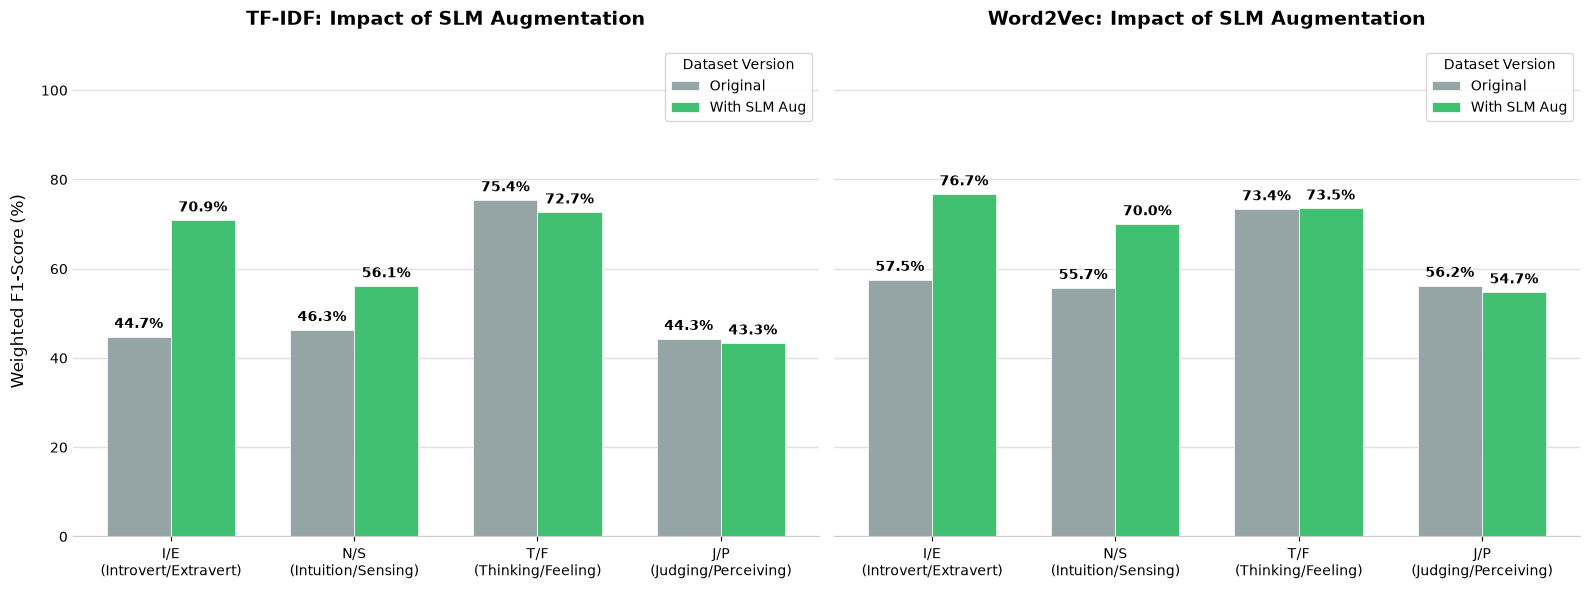

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_f1_impact_custom():
    labels_display = [
        'I/E\n(Introvert/Extravert)', 
        'N/S\n(Intuition/Sensing)', 
        'T/F\n(Thinking/Feeling)', 
        'J/P\n(Judging/Perceiving)'
    ]
    
    dict_keys = ['I_E', 'N_S', 'T_F', 'J_P']
    
    x = np.arange(len(labels_display))
    width = 0.35 

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
    
    color_original = '#95A5A6'  
    color_aug = '#40C070'       
    
    titles = ['TF-IDF: Impact of SLM Augmentation', 'Word2Vec: Impact of SLM Augmentation']
    encodings = ['TF_IDF', 'Word2Vec']
    
    for idx, encoding in enumerate(encodings):
        ax = axes[idx]
        
        baseline_scores = [comparison_metrics[encoding][dim]['baseline']['f1_score'] * 100 for dim in dict_keys]
        augmented_scores = [comparison_metrics[encoding][dim]['augmented']['f1_score'] * 100 for dim in dict_keys]
       
        rects1 = ax.bar(x - width/2, baseline_scores, width, label='Original', color=color_original, edgecolor='white', linewidth=0.5)
        rects2 = ax.bar(x + width/2, augmented_scores, width, label='With SLM Aug', color=color_aug, edgecolor='white', linewidth=0.5)
        
        ax.set_title(titles[idx], fontsize=14, fontweight='bold', pad=15)
        if idx == 0:
            ax.set_ylabel('Weighted F1-Score (%)', fontsize=12, labelpad=10)
        
        ax.set_xticks(x)
        ax.set_xticklabels(labels_display, fontsize=10)
        
        ax.set_ylim(0, 110)
        ax.yaxis.grid(True, color='#E0E0E0', linestyle='-', linewidth=1)
        ax.set_axisbelow(True) # Joga as linhas de grade para trás das barras
        
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_color('#CCCCCC')
        ax.tick_params(axis='y', length=0) 
        
        ax.legend(title='Dataset Version', loc='upper right', fontsize=10, title_fontsize=10)
        
        def add_labels(rects):
            for rect in rects:
                height = rect.get_height()
                ax.annotate(f'{height:.1f}%',
                            xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 4), 
                            textcoords="offset points",
                            ha='center', va='bottom', 
                            fontsize=10, fontweight='bold')
        
        add_labels(rects1)
        add_labels(rects2)

    plt.tight_layout()
    plt.show()

plot_f1_impact_custom()